Upload File

In [1]:
from google.colab import files
import pandas as pd
import json

uploaded = files.upload()

Saving predictions.csv to predictions.csv
Saving queries.json to queries.json


Load Predictions

In [5]:
predictions_df = pd.read_csv(
    "predictions.csv"
)

predictions_df.head()

,query_id,query,predicted_solution,top_5_case_ids
0,1,korupsi dana desa,"Menyatakan Terdakwa GUNTUR RAHMATULLAH, S.Pd B...","[3, 2, 16, 9, 6]"
1,2,penyalahgunaan anggaran,Menyatakan Terdakwa MOHAMAD BASYIR IDRIS terbu...,"[40, 39, 38, 37, 36]"
2,3,kredit fiktif bank,"Menyatakan Terdakwa ANDRI ACTOVAN, A.Md. tidak...","[7, 21, 40, 39, 36]"
3,4,penggelapan dana,Menyatakan Terdakwa MOHAMAD BASYIR IDRIS terbu...,"[40, 39, 38, 37, 36]"
4,5,kerugian negara,"Menyatakan terdakwa CAKRA ISKANDAR, S.E. tidak...","[21, 3, 13, 2, 9]"


Load Queries

In [6]:
with open(
    "queries.json",
    "r",
    encoding="utf-8"
) as f:

    queries = json.load(f)

queries_df = pd.DataFrame(
    queries
)

queries_df.head()

,query_id,query,ground_truth_case_id
0,1,korupsi dana desa,3
1,2,penyalahgunaan anggaran,26
2,3,kredit fiktif bank,7
3,4,penggelapan dana,19
4,5,kerugian negara,21


Gabungkan Ground Truth

In [7]:
eval_df = predictions_df.merge(

    queries_df[
        [
            "query_id",
            "ground_truth_case_id"
        ]
    ],

    on="query_id",

    how="left"

)

eval_df.head()

,query_id,query,predicted_solution,top_5_case_ids,ground_truth_case_id
0,1,korupsi dana desa,"Menyatakan Terdakwa GUNTUR RAHMATULLAH, S.Pd B...","[3, 2, 16, 9, 6]",3
1,2,penyalahgunaan anggaran,Menyatakan Terdakwa MOHAMAD BASYIR IDRIS terbu...,"[40, 39, 38, 37, 36]",26
2,3,kredit fiktif bank,"Menyatakan Terdakwa ANDRI ACTOVAN, A.Md. tidak...","[7, 21, 40, 39, 36]",7
3,4,penggelapan dana,Menyatakan Terdakwa MOHAMAD BASYIR IDRIS terbu...,"[40, 39, 38, 37, 36]",19
4,5,kerugian negara,"Menyatakan terdakwa CAKRA ISKANDAR, S.E. tidak...","[21, 3, 13, 2, 9]",21


Hitung Correct

In [8]:
hasil = []

for _, row in eval_df.iterrows():

    retrieved = ast.literal_eval(
        row["top_5_case_ids"]
    )

    gt = row[
        "ground_truth_case_id"
    ]

    hasil.append({

        "query_id":
        row["query_id"],

        "query":
        row["query"],

        "ground_truth_case_id":
        gt,

        "retrieved_case_ids":
        retrieved,

        "correct":
        gt in retrieved

    })

hasil_df = pd.DataFrame(
    hasil
)

hasil_df

,query_id,query,ground_truth_case_id,retrieved_case_ids,correct
0,1,korupsi dana desa,3,"[3, 2, 16, 9, 6]",True
1,2,penyalahgunaan anggaran,26,"[40, 39, 38, 37, 36]",False
2,3,kredit fiktif bank,7,"[7, 21, 40, 39, 36]",True
3,4,penggelapan dana,19,"[40, 39, 38, 37, 36]",False
4,5,kerugian negara,21,"[21, 3, 13, 2, 9]",True


Retrieval Accuracy

In [9]:
accuracy = hasil_df[
    "correct"
].mean()

print(
    f"Retrieval Accuracy = {accuracy:.4f}"
)

Retrieval Accuracy = 0.6000


Tabel Accuracy

In [10]:
metrics_df = pd.DataFrame({

    "Metric": [
        "Retrieval Accuracy"
    ],

    "Value": [
        accuracy
    ]

})

metrics_df

,Metric,Value
0,Retrieval Accuracy,0.6


Detail Evaluasi

In [11]:
hasil_df[
    [
        "query",
        "ground_truth_case_id",
        "retrieved_case_ids",
        "correct"
    ]
]

,query,ground_truth_case_id,retrieved_case_ids,correct
0,korupsi dana desa,3,"[3, 2, 16, 9, 6]",True
1,penyalahgunaan anggaran,26,"[40, 39, 38, 37, 36]",False
2,kredit fiktif bank,7,"[7, 21, 40, 39, 36]",True
3,penggelapan dana,19,"[40, 39, 38, 37, 36]",False
4,kerugian negara,21,"[21, 3, 13, 2, 9]",True


Accuracy Precision Recall F1

In [12]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

y_true = [1] * len(
    hasil_df
)

y_pred = (
    hasil_df["correct"]
    .astype(int)
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    "Accuracy :", accuracy
)

print(
    "Precision:", precision
)

print(
    "Recall   :", recall
)

print(
    "F1 Score :", f1
)

Accuracy : 0.6
Precision: 1.0
Recall   : 0.6
F1 Score : 0.75


Tabel Metric

In [13]:
metrics_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value": [

        accuracy,

        precision,

        recall,

        f1

    ]

})

metrics_df

,Metric,Value
0,Accuracy,0.60
1,Precision,1.00
2,Recall,0.60
3,F1 Score,0.75


Visualisasi

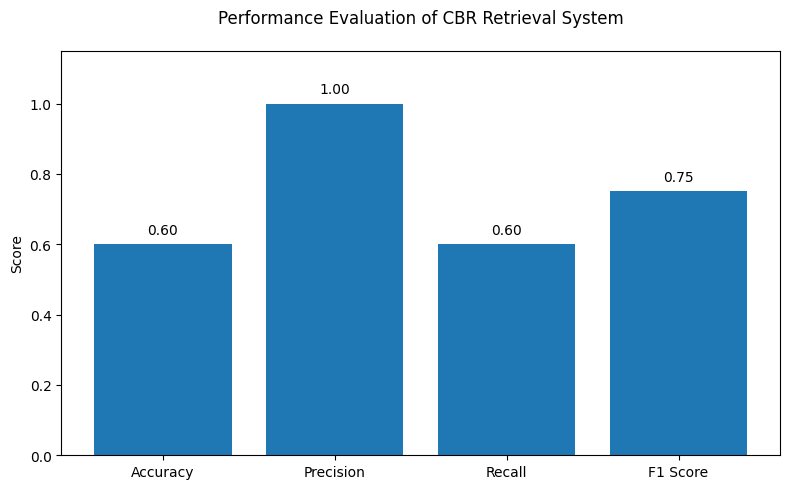

In [14]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,5)
)

bars = plt.bar(

    metrics_df["Metric"],

    metrics_df["Value"]

)

plt.ylim(
    0,
    1.15
)

plt.ylabel(
    "Score"
)

plt.title(
    "Performance Evaluation of CBR Retrieval System",
    pad=20
)

for bar in bars:

    y = bar.get_height()

    plt.text(

        bar.get_x()
        + bar.get_width()/2,

        y + 0.03,

        f"{y:.2f}",

        ha="center"

    )

plt.tight_layout()

plt.savefig(
    "evaluation_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Error Analysis

In [15]:
error_df = hasil_df[
    hasil_df["correct"] == False
]

error_df

,query_id,query,ground_truth_case_id,retrieved_case_ids,correct
1,2,penyalahgunaan anggaran,26,"[40, 39, 38, 37, 36]",False
3,4,penggelapan dana,19,"[40, 39, 38, 37, 36]",False


Simpan Hasil

In [16]:
metrics_df.to_csv(
    "retrieval_metrics.csv",
    index=False
)

error_df.to_csv(
    "error_analysis.csv",
    index=False
)

print(
    "File evaluasi berhasil dibuat"
)

File evaluasi berhasil dibuat
